# 03 — Mitigation d'équité in-processing (BERT)

**Mini-projet IA Responsable — Phase 2 / 5**

On entraîne deux variantes *in-processing* du baseline et on les compare strictement à la baseline P1 :

| Variante | Mécanisme | Hyperparamètres |
|---|---|---|
| **A — BCE pondérée** | Multiplie la perte par exemple : `w = 1 + λ_FP · 1[BPSN] + λ_FN · 1[BNSP]` (BPSN = non-toxique avec identité ; BNSP = toxique sans identité) | `λ_FP = λ_FN = 0.25` |
| **B — Multi-tâches identités** | Tête auxiliaire `Linear(768, 24)` prédisant la présence des 24 identités. `L = L_tox + α · L_identity` | `α = 0.1`, BCE par identité |

**Garanties de comparabilité** :
- Mêmes splits que P1 (rechargés depuis `reports/splits/split_ids.json`).
- Mêmes hyperparamètres BERT (lr, batch, epochs, seed, max_len).
- Mêmes métriques évaluées sur **exactement le même test set**.

**Sortie** : `reports/metrics/fair_weighted_metrics.json`, `reports/metrics/fair_multitask_metrics.json`, tableau comparatif consolidé `reports/metrics/comparison_baseline_vs_fair.json`, figures de delta.

---

**Sommaire**

0. Setup & configuration
1. Rechargement des données et des splits P1
2. Pondération BPSN/BNSP + identités cibles
3. Tokenisation (avec colonnes auxiliaires)
4. Variante A — BCE pondérée
5. Variante B — Multi-tâches identités
6. Tableau comparatif baseline vs A vs B
7. Visualisations comparatives
8. Sauvegarde + diagnostic


## 0. Setup & configuration


In [1]:
import gc
import json
import os
import sys

# Force PyTorch-only Transformers before importing any ML stack.
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["USE_TORCH"] = "1"

if "transformers" in sys.modules:
    raise RuntimeError(
        "Restart the notebook kernel, then rerun this cell. "
        "Transformers was already imported before USE_TF=0 took effect."
    )

import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from sklearn.metrics import roc_auc_score

from datasets import Dataset, DatasetDict
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BertModel,
    BertPreTrainedModel,
    Trainer,
    TrainingArguments,
)
from transformers.modeling_outputs import ModelOutput

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device : cuda
GPU    : NVIDIA GeForce RTX 4080 Laptop GPU
VRAM   : 12.9 GB


In [2]:
# === Chemins (alignés sur 02_baseline_bert.ipynb) ===
DATA_DIR = Path(
    os.environ.get(
        "JIGSAW_DATA_DIR",
        "../data",
    )
).expanduser().resolve()
TRAIN_CSV = DATA_DIR / "train.csv"

REPORTS_DIR = Path("../reports").resolve()
SPLITS_DIR  = REPORTS_DIR / "splits"
METRICS_DIR = REPORTS_DIR / "metrics"
FIGURES_DIR = REPORTS_DIR / "figures"
CHECKPOINTS_DIR_BASELINE = REPORTS_DIR / "checkpoints" / "baseline_bert"
CHECKPOINTS_DIR_FAIR_A   = REPORTS_DIR / "checkpoints" / "fair_weighted"
CHECKPOINTS_DIR_FAIR_B   = REPORTS_DIR / "checkpoints" / "fair_multitask"
for p in (CHECKPOINTS_DIR_FAIR_A, CHECKPOINTS_DIR_FAIR_B, METRICS_DIR, FIGURES_DIR):
    p.mkdir(parents=True, exist_ok=True)

# === Hyperparamètres BERT (IDENTIQUES à P1) ===
SEED               = 1337
MODEL_NAME         = "bert-base-uncased"
MAX_LEN            = 128
BATCH_SIZE_TRAIN   = 32
BATCH_SIZE_EVAL    = 64
LR                 = 2e-5
N_EPOCHS           = 2
WARMUP_RATIO       = 0.06
WEIGHT_DECAY       = 0.01
GRAD_ACCUM_STEPS   = 1
FP16               = True

# === Fairness ===
LAMBDA_FP = 0.25   # pénalité BPSN (non-toxique + identité)
LAMBDA_FN = 0.25   # pénalité BNSP (toxique  + sans identité)
ALPHA_IDENTITY = 0.10  # poids tâche auxiliaire identités (variante B)

# === Splits / seuils (IDENTIQUES à P1) ===
LABEL_THRESHOLD       = 0.5
IDENTITY_THRESHOLD    = 0.5
MIN_TEST_PER_IDENTITY = 500

print(f"DATA_DIR        : {DATA_DIR}  exists={DATA_DIR.exists()}")
print(f"SPLITS_DIR      : {SPLITS_DIR}")
print(f"CHECKPOINTS_DIR_FAIR_A : {CHECKPOINTS_DIR_FAIR_A}")
print(f"CHECKPOINTS_DIR_FAIR_B : {CHECKPOINTS_DIR_FAIR_B}")


DATA_DIR        : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\data  exists=True
SPLITS_DIR      : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\splits
CHECKPOINTS_DIR_FAIR_A : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\checkpoints\fair_weighted
CHECKPOINTS_DIR_FAIR_B : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\checkpoints\fair_multitask


In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def free_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

set_seed(SEED)


## 1. Rechargement des données et des splits P1

On rejoue **exactement** les ID-splits sauvegardés par le notebook baseline. Si `split_ids.json` n'existe pas, exécuter d'abord `02_baseline_bert.ipynb` jusqu'à la sauvegarde des splits.


In [4]:
IDENTITY_COLS = [
    "asian", "atheist", "bisexual", "black", "buddhist", "christian", "female",
    "heterosexual", "hindu", "homosexual_gay_or_lesbian",
    "intellectual_or_learning_disability", "jewish", "latino", "male", "muslim",
    "other_disability", "other_gender", "other_race_or_ethnicity", "other_religion",
    "other_sexual_orientation", "physical_disability", "psychiatric_or_mental_illness",
    "transgender", "white",
]
USE_COLS = ["id", "comment_text", "target"] + IDENTITY_COLS
N_ID = len(IDENTITY_COLS)
print(f"N identités : {N_ID}")


N identités : 24


In [5]:
assert TRAIN_CSV.exists(), f"Fichier introuvable: {TRAIN_CSV}"
splits_path = SPLITS_DIR / "split_ids.json"
assert splits_path.exists(), (
    f"Splits introuvables: {splits_path}\n"
    f"Exécuter d'abord 02_baseline_bert.ipynb jusqu'à la cellule 'split'."
)

with open(splits_path, encoding="utf-8") as f:
    splits = json.load(f)
print(f"Splits chargés : train={len(splits['train']):,} | val={len(splits['val']):,} | test={len(splits['test']):,}")
print(f"Seed splits   : {splits['seed']}  | n_rows_used : {splits['n_rows_used']:,}")

# Lecture CSV (les IDs présents dans splits définissent le sous-ensemble exact)
all_ids = set(splits["train"]) | set(splits["val"]) | set(splits["test"])
print(f"\nLecture {TRAIN_CSV} (filtré sur {len(all_ids):,} IDs) …")
df_full = pd.read_csv(TRAIN_CSV, usecols=USE_COLS)
df = df_full[df_full["id"].isin(all_ids)].reset_index(drop=True)
del df_full; gc.collect()
print(f"Lignes retenues : {len(df):,}")


Splits chargés : train=1,443,897 | val=180,486 | test=180,491
Seed splits   : 1337  | n_rows_used : 1,804,874

Lecture C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\data\train.csv (filtré sur 1,804,874 IDs) …
Lignes retenues : 1,804,874


In [6]:
# Étiquettes et flags identitaires (mêmes seuils que P1)
df["label"] = (df["target"].fillna(0) >= LABEL_THRESHOLD).astype(int)
for c in IDENTITY_COLS:
    df[c + "_bin"] = (df[c].fillna(0) >= IDENTITY_THRESHOLD).astype(int)
df["any_identity"] = df[[c + "_bin" for c in IDENTITY_COLS]].max(axis=1)

# Reload splits dans l'ordre original (préserve l'ordre des IDs sauvegardé)
def reload_split(d: pd.DataFrame, ids: list[int]) -> pd.DataFrame:
    return d.set_index("id").loc[ids].reset_index()

train_df = reload_split(df, splits["train"])
val_df   = reload_split(df, splits["val"])
test_df  = reload_split(df, splits["test"])

assert len(train_df) == len(splits["train"])
assert len(val_df)   == len(splits["val"])
assert len(test_df)  == len(splits["test"])

print(f"Train : {len(train_df):>9,} | toxic={train_df['label'].mean():.4f} | any_identity={train_df['any_identity'].mean():.4f}")
print(f"Val   : {len(val_df):>9,} | toxic={val_df['label'].mean():.4f}   | any_identity={val_df['any_identity'].mean():.4f}")
print(f"Test  : {len(test_df):>9,} | toxic={test_df['label'].mean():.4f}  | any_identity={test_df['any_identity'].mean():.4f}")


Train : 1,443,897 | toxic=0.0800 | any_identity=0.0944
Val   :   180,486 | toxic=0.0800   | any_identity=0.0944
Test  :   180,491 | toxic=0.0800  | any_identity=0.0944


## 2. Pondération BPSN/BNSP + identités cibles

**Pondération par exemple** (Variante A) :
$$w_i = 1 + \lambda_{FP} \cdot \mathbb{1}[\text{BPSN}_i] + \lambda_{FN} \cdot \mathbb{1}[\text{BNSP}_i]$$

- BPSN $\equiv$ exemple non-toxique mentionnant une identité → cible des **faux positifs** discriminatoires.
- BNSP $\equiv$ exemple toxique sans identité explicite → cible des **faux négatifs** (rééquilibre le signal toxique général).

**Cibles identitaires** (Variante B) : on garde les valeurs **continues** dans `[0,1]` (fraction d'annotateurs) — plus informatif que la binarisation, et compatible avec une BCE par dimension.


In [7]:
def compute_loss_weight(label: np.ndarray, any_id: np.ndarray) -> np.ndarray:
    is_bpsn = ((label == 0) & (any_id == 1)).astype(float)
    is_bnsp = ((label == 1) & (any_id == 0)).astype(float)
    return 1.0 + LAMBDA_FP * is_bpsn + LAMBDA_FN * is_bnsp


for d in (train_df, val_df, test_df):
    d["loss_weight"] = compute_loss_weight(d["label"].to_numpy(), d["any_identity"].to_numpy())
    # identity_labels : tableau (n, 24) de valeurs continues dans [0,1]
    d["identity_labels"] = d[IDENTITY_COLS].fillna(0.0).astype(np.float32).values.tolist()

# Diagnostic des poids
w = train_df["loss_weight"].to_numpy()
print(f"Poids train : min={w.min():.2f} | mean={w.mean():.3f} | max={w.max():.2f}")
print(f"  w == 1.00          : {(w == 1.0).mean():.3%} (cas neutres)")
print(f"  w == 1+λ_FP={1+LAMBDA_FP:.2f}  : {(np.isclose(w, 1+LAMBDA_FP)).mean():.3%} (BPSN)")
print(f"  w == 1+λ_FN={1+LAMBDA_FN:.2f}  : {(np.isclose(w, 1+LAMBDA_FN)).mean():.3%} (BNSP)")


Poids train : min=1.00 | mean=1.036 | max=1.25
  w == 1.00          : 85.666% (cas neutres)
  w == 1+λ_FP=1.25  : 14.334% (BPSN)
  w == 1+λ_FN=1.25  : 14.334% (BNSP)


## 3. Tokenisation et `Dataset` HuggingFace

On ajoute deux colonnes auxiliaires : `loss_weight` (float) pour la variante A, et `identity_labels` (vecteur 24 floats) pour la variante B. Les deux variantes lisent le même `DatasetDict` ; chacune ne consomme que ce qu'elle utilise dans son `compute_loss`.


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def to_hf_ds(d: pd.DataFrame) -> Dataset:
    sub = d[["comment_text", "label", "loss_weight", "identity_labels"]].copy()
    sub["comment_text"] = sub["comment_text"].fillna("").astype(str)
    sub = sub.rename(columns={"comment_text": "text"})
    return Dataset.from_pandas(sub, preserve_index=False)

dsd = DatasetDict(train=to_hf_ds(train_df), val=to_hf_ds(val_df), test=to_hf_ds(test_df))

def tokenize(batch):
    texts = ["" if text is None else str(text) for text in batch["text"]]
    return tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

print("Tokenisation …")
dsd_tok = dsd.map(tokenize, batched=True, remove_columns=["text"], desc="tokenize")
dsd_tok.set_format("torch")
print(dsd_tok)
print("\nColonnes train :", dsd_tok["train"].column_names)


Tokenisation …


tokenize:   0%|          | 0/1443897 [00:00<?, ? examples/s]

tokenize:   0%|          | 0/180486 [00:00<?, ? examples/s]

tokenize:   0%|          | 0/180491 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'loss_weight', 'identity_labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1443897
    })
    val: Dataset({
        features: ['label', 'loss_weight', 'identity_labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 180486
    })
    test: Dataset({
        features: ['label', 'loss_weight', 'identity_labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 180491
    })
})

Colonnes train : ['label', 'loss_weight', 'identity_labels', 'input_ids', 'token_type_ids', 'attention_mask']


### Helpers partagés (sigmoid, compute_metrics, inference, fairness)


In [9]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def compute_metrics_auc(eval_pred):
    logits, labels = eval_pred
    # Pour les modèles multi-output, on prend la première sortie (logits toxicité)
    if isinstance(logits, tuple):
        logits = logits[0]
    logits = np.asarray(logits).reshape(-1)
    labels = np.asarray(labels).reshape(-1)
    return {"roc_auc": float(roc_auc_score(labels, sigmoid(logits)))}


@torch.inference_mode()
def predict_proba(model, tokenizer, texts, *, max_length, batch_size=64, device=DEVICE):
    model.to(device).eval()
    all_logits = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i + batch_size],
            truncation=True, padding=True, max_length=max_length, return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        out = model(**enc)
        all_logits.append(out.logits.detach().cpu().numpy())

    logits = np.concatenate(all_logits, axis=0)
    logits = np.asarray(logits)

    if logits.ndim == 1:
        return sigmoid(logits), logits

    if logits.ndim == 2 and logits.shape[1] == 1:
        logits_1d = logits[:, 0]
        return sigmoid(logits_1d), logits_1d

    if logits.ndim == 2 and logits.shape[1] == 2:
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(shifted)
        return exp_logits[:, 1] / exp_logits.sum(axis=1), logits

    raise ValueError(f"Format de logits non supporté pour une classification binaire: {logits.shape}")


def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= 0.5).astype(int)
    conf = np.where(y_pred == 1, y_prob, 1.0 - y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece, n = 0.0, len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf >= lo) & (conf < hi if i < n_bins - 1 else conf <= hi)
        if not np.any(mask):
            continue
        acc = float(np.mean(y_pred[mask] == y_true[mask]))
        avg_conf = float(np.mean(conf[mask]))
        ece += (np.sum(mask) / n) * abs(acc - avg_conf)
    return float(ece)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if y_true.size == 0 or y_true.min() == y_true.max():
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def compute_identity_aucs(y_true, y_pred, sub_mask):
    sub = sub_mask.astype(bool); bg = ~sub
    return {
        "subgroup_auc": safe_auc(y_true[sub], y_pred[sub]),
        "bpsn_auc":     safe_auc(
            y_true[(sub & (y_true == 0)) | (bg & (y_true == 1))],
            y_pred[(sub & (y_true == 0)) | (bg & (y_true == 1))],
        ),
        "bnsp_auc":     safe_auc(
            y_true[(sub & (y_true == 1)) | (bg & (y_true == 0))],
            y_pred[(sub & (y_true == 1)) | (bg & (y_true == 0))],
        ),
        "n_subgroup":   int(sub.sum()),
    }


def generalized_mean(values, p=-5.0):
    arr = np.asarray([v for v in values if np.isfinite(v)], dtype=float)
    if arr.size == 0:
        return float("nan")
    return float(np.power(np.mean(np.power(arr, p)), 1.0 / p))


P_GEN_MEAN = -5.0


def full_evaluate(model, tokenizer, test_df, *, label="model") -> dict:
    texts = test_df["comment_text"].astype(str).tolist()
    y_true = test_df["label"].to_numpy()
    probs, logits = predict_proba(model, tokenizer, texts,
                                  max_length=MAX_LEN, batch_size=BATCH_SIZE_EVAL)

    overall_auc = float(roc_auc_score(y_true, probs))
    ece = expected_calibration_error(y_true, probs, n_bins=15)
    accuracy = float(np.mean((probs >= 0.5).astype(int) == y_true))

    records = []
    for col in IDENTITY_COLS:
        sub_mask = test_df[col + "_bin"].to_numpy().astype(bool)
        if sub_mask.sum() < MIN_TEST_PER_IDENTITY:
            continue
        aucs = compute_identity_aucs(y_true, probs, sub_mask)
        records.append({"identity": col, **aucs})
    fairness_df = pd.DataFrame(records).sort_values("subgroup_auc").reset_index(drop=True)

    gm_sub  = generalized_mean(fairness_df["subgroup_auc"], p=P_GEN_MEAN)
    gm_bpsn = generalized_mean(fairness_df["bpsn_auc"],     p=P_GEN_MEAN)
    gm_bnsp = generalized_mean(fairness_df["bnsp_auc"],     p=P_GEN_MEAN)
    final_score = float(np.nanmean([overall_auc, gm_sub, gm_bpsn, gm_bnsp]))

    out = {
        "label": label,
        "overall_auc": overall_auc,
        "accuracy_at_0.5": accuracy,
        "ece_15bins": ece,
        "generalized_mean": {"subgroup_auc": gm_sub, "bpsn_auc": gm_bpsn,
                              "bnsp_auc": gm_bnsp, "p": P_GEN_MEAN},
        "jigsaw_final_score": final_score,
        "n_identities_used": len(fairness_df),
        "per_identity": fairness_df.set_index("identity").to_dict(orient="index"),
        "probs": probs,
        "_fairness_df": fairness_df,
    }
    print(f"\n[{label}]  Overall AUC = {overall_auc:.4f}  |  ECE = {ece:.4f}  |  Jigsaw = {final_score:.4f}")
    print(f"  Min Subgroup AUC : {fairness_df['subgroup_auc'].min():.4f}  ({fairness_df.iloc[0]['identity']})")
    print(f"  Min BPSN AUC     : {fairness_df['bpsn_auc'].min():.4f}  ({fairness_df.loc[fairness_df['bpsn_auc'].idxmin(), 'identity']})")
    print(f"  Min BNSP AUC     : {fairness_df['bnsp_auc'].min():.4f}  ({fairness_df.loc[fairness_df['bnsp_auc'].idxmin(), 'identity']})")
    return out


## 4. Variante A — BCE pondérée BPSN/BNSP

`BCEWithLogitsLoss(reduction="none")` × `loss_weight`, puis moyenne. La pondération est lue à chaque batch sur la colonne `loss_weight` ajoutée à la HuggingFace `Dataset`.


In [27]:
class BCEWeightedTrainer(Trainer):
    """BCE pondérée par exemple via la clé `loss_weight` dans les inputs."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").float()
        loss_weight = inputs.pop("loss_weight").float()
        # On ignore identity_labels pour la variante A
        inputs.pop("identity_labels", None)
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        per_ex = torch.nn.functional.binary_cross_entropy_with_logits(
            logits, labels, reduction="none"
        )
        loss = (per_ex * loss_weight).mean()
        return (loss, outputs) if return_outputs else loss


In [28]:
set_seed(SEED)
model_A = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1)

training_args_A = TrainingArguments(
    output_dir=str(CHECKPOINTS_DIR_FAIR_A),
    num_train_epochs=N_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE_TRAIN,
    per_device_eval_batch_size=BATCH_SIZE_EVAL,
    learning_rate=LR, weight_decay=WEIGHT_DECAY, warmup_ratio=WARMUP_RATIO,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    fp16=FP16 and torch.cuda.is_available(),
    eval_strategy="steps", eval_steps=1000,
    save_strategy="steps", save_steps=1000, save_total_limit=2,
    logging_strategy="steps", logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc", greater_is_better=True,
    seed=SEED, report_to=[],
    remove_unused_columns=False,  # IMPORTANT : conserve loss_weight / identity_labels
)

trainer_A = BCEWeightedTrainer(
    model=model_A, args=training_args_A,
    train_dataset=dsd_tok["train"], eval_dataset=dsd_tok["val"],
    tokenizer=tokenizer, compute_metrics=compute_metrics_auc,
)

print("Entraînement Variante A (BCE pondérée) …")
train_result_A = trainer_A.train()
print("\nMétriques d'entraînement A :")
for k, v in train_result_A.metrics.items():
    print(f"  {k:<28s} {v}")

trainer_A.save_model(str(CHECKPOINTS_DIR_FAIR_A))
tokenizer.save_pretrained(str(CHECKPOINTS_DIR_FAIR_A))
print(f"Modèle A sauvegardé : {CHECKPOINTS_DIR_FAIR_A}")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Entraînement Variante A (BCE pondérée) …


Step,Training Loss,Validation Loss,Roc Auc
1000,0.220400,0.198849,0.893310
2000,0.168400,0.169368,0.939950
3000,0.158200,0.157023,0.948619
4000,0.161900,0.175808,0.935217
5000,0.171800,0.153895,0.948188
6000,0.156400,0.150856,0.953349
7000,0.166100,0.145984,0.956110
8000,0.160400,0.147673,0.954695
9000,0.168800,0.147406,0.954863
10000,0.157500,0.154289,0.956030



Métriques d'entraînement A :
  train_runtime                24317.772
  train_samples_per_second     118.752
  train_steps_per_second       3.711
  total_flos                   1.899509262425349e+17
  train_loss                   0.13592480617150532
  epoch                        2.0
Modèle A sauvegardé : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\checkpoints\fair_weighted


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

tokenizer_A = AutoTokenizer.from_pretrained(str(CHECKPOINTS_DIR_FAIR_A), use_fast=True)
model_A = AutoModelForSequenceClassification.from_pretrained(str(CHECKPOINTS_DIR_FAIR_A))

results_A = full_evaluate(model_A, tokenizer_A, test_df, label="fair_weighted")

test_predictions_A = test_df[["id", "comment_text", "label"]].copy()
test_predictions_A["pred_prob"] = results_A["probs"]
test_predictions_A.to_parquet(METRICS_DIR / "test_predictions_fair_weighted.parquet", index=False)

print(results_A["overall_auc"])

# results_A = full_evaluate(model_A, tokenizer, test_df, label="fair_weighted")

# # Persistance brute
# test_predictions_A = test_df[["id", "comment_text", "label"]].copy()
# test_predictions_A["pred_prob"] = results_A["probs"]
# test_predictions_A.to_parquet(METRICS_DIR / "test_predictions_fair_weighted.parquet", index=False)
print(f"Prédictions A : {METRICS_DIR / 'test_predictions_fair_weighted.parquet'}")

# Libère la VRAM pour la variante B
del model_A, tokenizer_A
free_cuda()



[fair_weighted]  Overall AUC = 0.9649  |  ECE = 0.0165  |  Jigsaw = 0.9260
  Min Subgroup AUC : 0.8457  (black)
  Min BPSN AUC     : 0.8467  (black)
  Min BNSP AUC     : 0.9471  (christian)
0.9649024824323832
Prédictions A : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\metrics\test_predictions_fair_weighted.parquet


NameError: name 'trainer_A' is not defined

In [12]:
del tokenizer_A
free_cuda()

## 5. Variante B — Multi-tâches identités

Architecture : `BERT → pooler_output (768) → [Linear(768, 1), Linear(768, 24)]`. Perte totale :
$$L = \mathrm{BCE}(\hat z_\text{tox}, y_\text{tox}) + \alpha \cdot \mathrm{BCE}(\hat z_\text{id}, y_\text{id})$$

avec $\alpha = 0.10$ et $y_\text{id} \in [0,1]^{24}$ (valeurs continues de fraction d'annotateurs). L'objectif : forcer l'encodeur à **représenter explicitement** les identités dans son embedding pour qu'elles cessent d'être absorbées dans le signal de toxicité.


In [13]:
@dataclass
class ToxicityIdentityOutput(ModelOutput):
    loss: Optional[torch.Tensor] = None
    logits: Optional[torch.Tensor] = None
    identity_logits: Optional[torch.Tensor] = None


class BertForToxicityAndIdentity(BertPreTrainedModel):
    """BERT + tête toxicité (1 logit) + tête identité (24 logits)."""

    def __init__(self, config, num_identities: int = N_ID):
        super().__init__(config)
        self.num_identities = int(num_identities)
        self.bert = BertModel(config, add_pooling_layer=True)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.toxicity_classifier = nn.Linear(config.hidden_size, 1)
        self.identity_classifier = nn.Linear(config.hidden_size, self.num_identities)
        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, **kwargs):
        # Ces colonnes appartiennent au Trainer/dataset, pas au BertModel interne.
        kwargs.pop("labels", None)
        kwargs.pop("identity_labels", None)
        kwargs.pop("loss_weight", None)
        outputs = self.bert(
            input_ids=input_ids, attention_mask=attention_mask,
            token_type_ids=token_type_ids, **kwargs,
        )
        pooled = self.dropout(outputs.pooler_output)
        tox_logits = self.toxicity_classifier(pooled).squeeze(-1)
        id_logits  = self.identity_classifier(pooled)
        return ToxicityIdentityOutput(logits=tox_logits, identity_logits=id_logits)


class MultiTaskBCETrainer(Trainer):
    """L = BCE(tox) + α · BCE(identity). Lit `identity_labels` (24-dim)."""

    def __init__(self, *args, identity_loss_weight: float = ALPHA_IDENTITY, **kwargs):
        super().__init__(*args, **kwargs)
        self.identity_loss_weight = float(identity_loss_weight)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels         = inputs.pop("labels").float()
        identity_lab   = inputs.pop("identity_labels").float()
        inputs.pop("loss_weight", None)  # non utilisé en variante B
        outputs = model(**inputs)
        tox_loss = torch.nn.functional.binary_cross_entropy_with_logits(outputs.logits, labels)
        id_loss  = torch.nn.functional.binary_cross_entropy_with_logits(outputs.identity_logits, identity_lab)
        loss = tox_loss + self.identity_loss_weight * id_loss
        return (loss, outputs) if return_outputs else loss


In [22]:
set_seed(SEED)
model_B = BertForToxicityAndIdentity.from_pretrained(
    MODEL_NAME, num_identities=N_ID,
)

training_args_B = TrainingArguments(
    output_dir=str(CHECKPOINTS_DIR_FAIR_B),
    num_train_epochs=N_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE_TRAIN,
    per_device_eval_batch_size=BATCH_SIZE_EVAL,
    learning_rate=LR, weight_decay=WEIGHT_DECAY, warmup_ratio=WARMUP_RATIO,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    fp16=FP16 and torch.cuda.is_available(),
    eval_strategy="steps", eval_steps=1000,
    save_strategy="steps", save_steps=1000, save_total_limit=2,
    logging_strategy="steps", logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc", greater_is_better=True,
    seed=SEED, report_to=[],
    remove_unused_columns=False,
    label_names=["labels"],
)

trainer_B = MultiTaskBCETrainer(
    model=model_B, args=training_args_B,
    train_dataset=dsd_tok["train"], eval_dataset=dsd_tok["val"],
    tokenizer=tokenizer, compute_metrics=compute_metrics_auc,
    identity_loss_weight=ALPHA_IDENTITY,
)

print("Entraînement Variante B (multi-tâches identités) …")
train_result_B = trainer_B.train()
print("\nMétriques d'entraînement B :")
for k, v in train_result_B.metrics.items():
    print(f"  {k:<28s} {v}")

trainer_B.save_model(str(CHECKPOINTS_DIR_FAIR_B))
tokenizer.save_pretrained(str(CHECKPOINTS_DIR_FAIR_B))
# Persiste aussi la liste d'identités pour le reload (utile pour XAI/robustesse)
with open(CHECKPOINTS_DIR_FAIR_B / "identity_columns.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(IDENTITY_COLS))
print(f"Modèle B sauvegardé : {CHECKPOINTS_DIR_FAIR_B}")


Some weights of BertForToxicityAndIdentity were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['identity_classifier.bias', 'identity_classifier.weight', 'toxicity_classifier.bias', 'toxicity_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Entraînement Variante B (multi-tâches identités) …


Step,Training Loss,Validation Loss,Roc Auc
1000,0.229000,0.203137,0.912851
2000,0.160100,0.158632,0.940345
3000,0.143500,0.145167,0.948527
4000,0.145600,0.153422,0.941720
5000,0.152700,0.137387,0.950163
6000,0.142300,0.136561,0.953301
7000,0.147100,0.129921,0.956265
8000,0.140700,0.128243,0.956532
9000,0.151300,0.128848,0.954504
10000,0.135300,0.140906,0.956200



Métriques d'entraînement B :
  train_runtime                45970.4064
  train_samples_per_second     62.819
  train_steps_per_second       1.963
  total_flos                   1.8999185843535206e+17
  train_loss                   0.12045342048470695
  epoch                        2.0
Modèle B sauvegardé : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\checkpoints\fair_multitask


In [17]:
from transformers import AutoTokenizer

tokenizer_B = AutoTokenizer.from_pretrained(str(CHECKPOINTS_DIR_FAIR_B), use_fast=True)
model_B = BertForToxicityAndIdentity.from_pretrained(
    str(CHECKPOINTS_DIR_FAIR_B), num_identities=N_ID,
)

results_B = full_evaluate(model_B, tokenizer_B, test_df, label="fair_multitask")

test_predictions_B = test_df[["id", "comment_text", "label"]].copy()
test_predictions_B["pred_prob"] = results_B["probs"]
test_predictions_B.to_parquet(METRICS_DIR / "test_predictions_fair_multitask.parquet", index=False)

print(results_B["overall_auc"])
print(f"Prédictions B : {METRICS_DIR / 'test_predictions_fair_multitask.parquet'}")

# Libère la VRAM pour la suite
del model_B, tokenizer_B
free_cuda()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\checkpoints\fair_multitask and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ValueError: y should be a 1d array, got an array of shape (180491, 2) instead.

In [18]:
if "results_B" not in globals():
    tokenizer_B = AutoTokenizer.from_pretrained(str(CHECKPOINTS_DIR_FAIR_B), use_fast=True)
    model_B = BertForToxicityAndIdentity.from_pretrained(
        str(CHECKPOINTS_DIR_FAIR_B), num_identities=N_ID,
    )
    results_B = full_evaluate(model_B, tokenizer_B, test_df, label="fair_multitask")

    test_predictions_B = test_df[["id", "comment_text", "label"]].copy()
    test_predictions_B["pred_prob"] = results_B["probs"]
    test_predictions_B.to_parquet(METRICS_DIR / "test_predictions_fair_multitask.parquet", index=False)
    print(f"Prédictions B : {METRICS_DIR / 'test_predictions_fair_multitask.parquet'}")

    del model_B, tokenizer_B
    free_cuda()
else:
    print("results_B existe déjà en mémoire.")



[fair_multitask]  Overall AUC = 0.9648  |  ECE = 0.0146  |  Jigsaw = 0.9253
  Min Subgroup AUC : 0.8475  (black)
  Min BPSN AUC     : 0.8367  (black)
  Min BNSP AUC     : 0.9538  (christian)
Prédictions B : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\metrics\test_predictions_fair_multitask.parquet


## 6. Tableau comparatif baseline vs A vs B

Lecture des deltas :
- **Δoverall_auc** quantifie le coût en performance globale de la mitigation (typiquement négatif et faible).
- **Δjigsaw_final_score** capture le **gain net** : pénalise les pires sous-groupes via la moyenne généralisée *p* = −5.
- **Δ min(BPSN_AUC)** : c'est la métrique critique — le pire sous-groupe FP doit s'améliorer significativement.


In [19]:
# Recharge les métriques baseline (P1)
baseline_path = METRICS_DIR / "baseline_metrics.json"
assert baseline_path.exists(), f"Baseline introuvable : {baseline_path}. Exécuter d'abord 02_baseline_bert.ipynb."
with open(baseline_path, encoding="utf-8") as f:
    baseline = json.load(f)

# Reconstruit le DataFrame fairness baseline
baseline_records = [{"identity": k, **v} for k, v in baseline["per_identity"].items()]
baseline_fairness_df = pd.DataFrame(baseline_records).sort_values("identity").reset_index(drop=True)

print(f"[baseline]  Overall AUC = {baseline['overall_auc']:.4f}  |  "
      f"ECE = {baseline['ece_15bins']:.4f}  |  Jigsaw = {baseline['jigsaw_final_score']:.4f}")
print(f"  N identités évaluées : {baseline['n_identities_used']}")


[baseline]  Overall AUC = 0.9644  |  ECE = 0.0156  |  Jigsaw = 0.9235
  N identités évaluées : 8


In [20]:
def summary_row(results: dict, fairness_df: pd.DataFrame) -> dict:
    return {
        "overall_auc":         results["overall_auc"],
        "ece_15bins":          results["ece_15bins"],
        "jigsaw_final_score":  results["jigsaw_final_score"],
        "gm_subgroup":         results["generalized_mean"]["subgroup_auc"],
        "gm_bpsn":             results["generalized_mean"]["bpsn_auc"],
        "gm_bnsp":             results["generalized_mean"]["bnsp_auc"],
        "min_subgroup_auc":    float(fairness_df["subgroup_auc"].min()),
        "min_bpsn_auc":        float(fairness_df["bpsn_auc"].min()),
        "min_bnsp_auc":        float(fairness_df["bnsp_auc"].min()),
    }


baseline_row = {
    "overall_auc":        baseline["overall_auc"],
    "ece_15bins":         baseline["ece_15bins"],
    "jigsaw_final_score": baseline["jigsaw_final_score"],
    "gm_subgroup":        baseline["generalized_mean"]["subgroup_auc"],
    "gm_bpsn":            baseline["generalized_mean"]["bpsn_auc"],
    "gm_bnsp":            baseline["generalized_mean"]["bnsp_auc"],
    "min_subgroup_auc":   float(baseline_fairness_df["subgroup_auc"].min()),
    "min_bpsn_auc":       float(baseline_fairness_df["bpsn_auc"].min()),
    "min_bnsp_auc":       float(baseline_fairness_df["bnsp_auc"].min()),
}
A_row = summary_row(results_A, results_A["_fairness_df"])
B_row = summary_row(results_B, results_B["_fairness_df"])

summary = pd.DataFrame(
    [baseline_row, A_row, B_row],
    index=["baseline", "fair_weighted (A)", "fair_multitask (B)"],
)

# Deltas par rapport au baseline
delta = summary.subtract(summary.loc["baseline"])
delta.index = ["Δ baseline", "Δ A − baseline", "Δ B − baseline"]
delta.loc["Δ baseline"] = 0.0

print("=== MÉTRIQUES BRUTES ===")
print(summary.round(4).to_string())
print("\n=== DELTAS (versus baseline) ===")
print(delta.round(4).to_string())


=== MÉTRIQUES BRUTES ===
                    overall_auc  ece_15bins  jigsaw_final_score  gm_subgroup  gm_bpsn  gm_bnsp  min_subgroup_auc  min_bpsn_auc  min_bnsp_auc
baseline                 0.9644      0.0156              0.9235       0.8808   0.8829   0.9659            0.8430        0.8350        0.9520
fair_weighted (A)        0.9649      0.0165              0.9260       0.8830   0.8932   0.9627            0.8457        0.8467        0.9471
fair_multitask (B)       0.9648      0.0146              0.9253       0.8855   0.8838   0.9672            0.8475        0.8367        0.9538

=== DELTAS (versus baseline) ===
                overall_auc  ece_15bins  jigsaw_final_score  gm_subgroup  gm_bpsn  gm_bnsp  min_subgroup_auc  min_bpsn_auc  min_bnsp_auc
Δ baseline           0.0000      0.0000              0.0000       0.0000   0.0000   0.0000            0.0000        0.0000        0.0000
Δ A − baseline       0.0005      0.0009              0.0024       0.0022   0.0103  -0.0032            0

In [21]:
comparison = {
    "models": {
        "baseline":       baseline_row,
        "fair_weighted":  A_row,
        "fair_multitask": B_row,
    },
    "deltas_vs_baseline": {
        "fair_weighted":  {k: float(A_row[k] - baseline_row[k]) for k in baseline_row},
        "fair_multitask": {k: float(B_row[k] - baseline_row[k]) for k in baseline_row},
    },
    "hyperparameters_fair": {
        "lambda_FP": LAMBDA_FP, "lambda_FN": LAMBDA_FN,
        "alpha_identity": ALPHA_IDENTITY,
    },
    "seed": SEED,
    "min_test_per_identity": MIN_TEST_PER_IDENTITY,
}

with open(METRICS_DIR / "fair_weighted_metrics.json", "w", encoding="utf-8") as f:
    res = {k: v for k, v in results_A.items() if k not in ("probs", "_fairness_df")}
    res["lambda_FP"] = LAMBDA_FP; res["lambda_FN"] = LAMBDA_FN
    json.dump(res, f, indent=2, default=float)

with open(METRICS_DIR / "fair_multitask_metrics.json", "w", encoding="utf-8") as f:
    res = {k: v for k, v in results_B.items() if k not in ("probs", "_fairness_df")}
    res["alpha_identity"] = ALPHA_IDENTITY
    json.dump(res, f, indent=2, default=float)

with open(METRICS_DIR / "comparison_baseline_vs_fair.json", "w", encoding="utf-8") as f:
    json.dump(comparison, f, indent=2, default=float)

print(f"Écrits : fair_weighted_metrics.json, fair_multitask_metrics.json, comparison_baseline_vs_fair.json")


Écrits : fair_weighted_metrics.json, fair_multitask_metrics.json, comparison_baseline_vs_fair.json


## 7. Visualisations comparatives


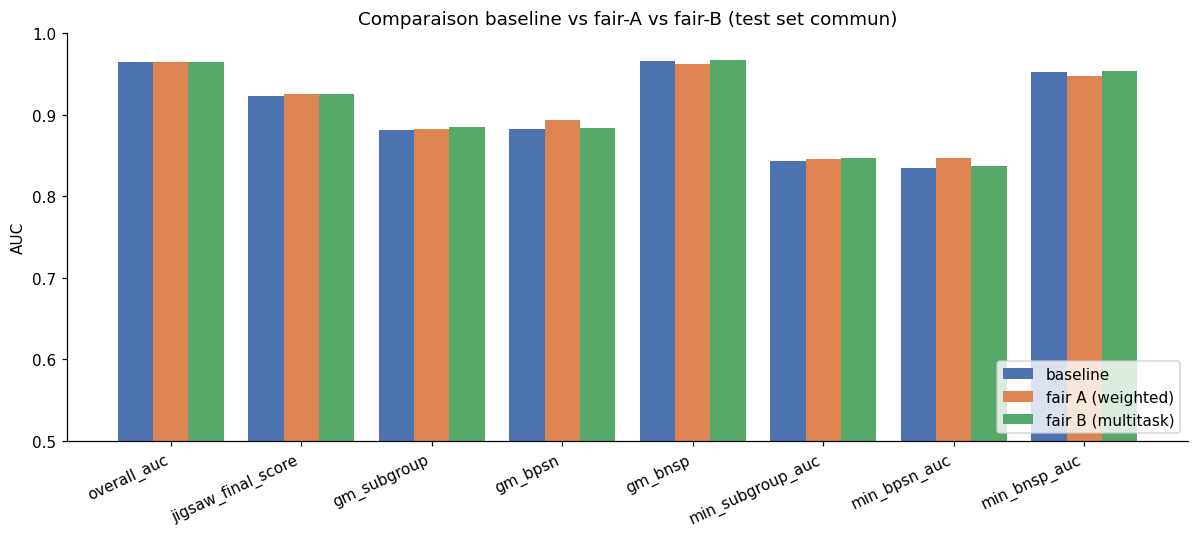

Figure : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\figures\comparison_aggregate_metrics.png


In [22]:
# Barres comparatives sur les métriques agrégées
metrics_to_plot = ["overall_auc", "jigsaw_final_score", "gm_subgroup", "gm_bpsn", "gm_bnsp",
                    "min_subgroup_auc", "min_bpsn_auc", "min_bnsp_auc"]
plot_df = summary[metrics_to_plot].T

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(metrics_to_plot))
w = 0.27
ax.bar(x - w, plot_df["baseline"],          w, label="baseline",      color="#4C72B0")
ax.bar(x,     plot_df["fair_weighted (A)"], w, label="fair A (weighted)",  color="#DD8452")
ax.bar(x + w, plot_df["fair_multitask (B)"], w, label="fair B (multitask)", color="#55A868")
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot, rotation=25, ha="right")
ax.set_ylim(0.5, 1.0); ax.set_ylabel("AUC")
ax.set_title("Comparaison baseline vs fair-A vs fair-B (test set commun)")
ax.legend(loc="lower right")
plt.tight_layout()
fig_path = FIGURES_DIR / "comparison_aggregate_metrics.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure : {fig_path}")


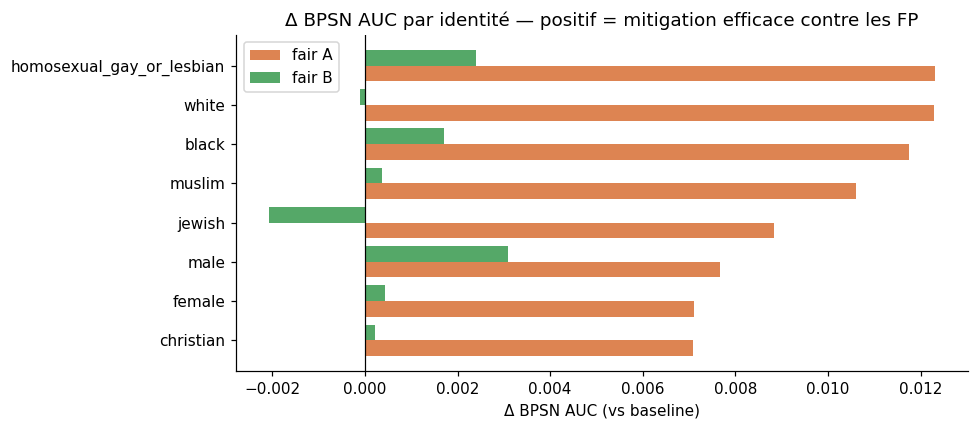

Figure : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\figures\delta_bpsn_per_identity.png


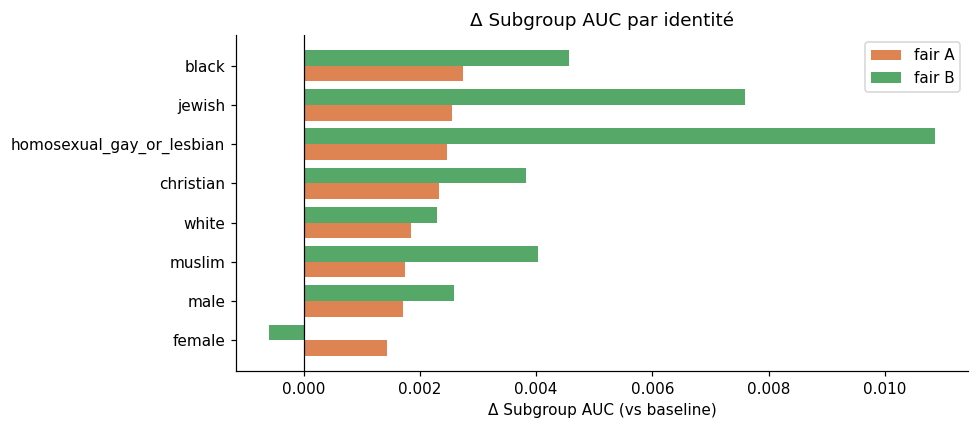

Figure : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\figures\delta_subgroup_per_identity.png


In [23]:
# Δ BPSN par identité (positif = meilleur que baseline)
def reindex_on_identity(d: pd.DataFrame) -> pd.DataFrame:
    return d.set_index("identity")

base_id = reindex_on_identity(baseline_fairness_df)
A_id    = reindex_on_identity(results_A["_fairness_df"])
B_id    = reindex_on_identity(results_B["_fairness_df"])

common = sorted(set(base_id.index) & set(A_id.index) & set(B_id.index))
delta_bpsn = pd.DataFrame({
    "fair A − baseline": A_id.loc[common, "bpsn_auc"] - base_id.loc[common, "bpsn_auc"],
    "fair B − baseline": B_id.loc[common, "bpsn_auc"] - base_id.loc[common, "bpsn_auc"],
}).sort_values("fair A − baseline")

fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(delta_bpsn))))
y = np.arange(len(delta_bpsn))
w = 0.4
ax.barh(y - w/2, delta_bpsn["fair A − baseline"], w, color="#DD8452", label="fair A")
ax.barh(y + w/2, delta_bpsn["fair B − baseline"], w, color="#55A868", label="fair B")
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(delta_bpsn.index)
ax.set_xlabel("Δ BPSN AUC (vs baseline)")
ax.set_title("Δ BPSN AUC par identité — positif = mitigation efficace contre les FP")
ax.legend()
plt.tight_layout()
fig_path = FIGURES_DIR / "delta_bpsn_per_identity.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure : {fig_path}")

# Δ Subgroup AUC (capacité à discriminer dans le sous-groupe)
delta_sub = pd.DataFrame({
    "fair A − baseline": A_id.loc[common, "subgroup_auc"] - base_id.loc[common, "subgroup_auc"],
    "fair B − baseline": B_id.loc[common, "subgroup_auc"] - base_id.loc[common, "subgroup_auc"],
}).sort_values("fair A − baseline")

fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(delta_sub))))
y = np.arange(len(delta_sub))
ax.barh(y - w/2, delta_sub["fair A − baseline"], w, color="#DD8452", label="fair A")
ax.barh(y + w/2, delta_sub["fair B − baseline"], w, color="#55A868", label="fair B")
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(delta_sub.index)
ax.set_xlabel("Δ Subgroup AUC (vs baseline)")
ax.set_title("Δ Subgroup AUC par identité")
ax.legend()
plt.tight_layout()
fig_path = FIGURES_DIR / "delta_subgroup_per_identity.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure : {fig_path}")


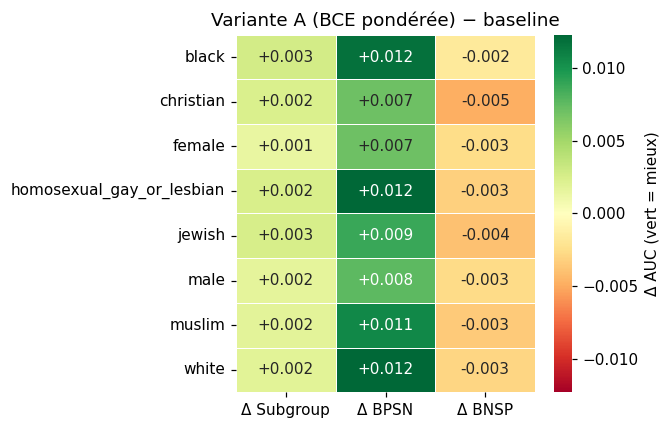

Figure : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\figures\delta_heatmap_A.png


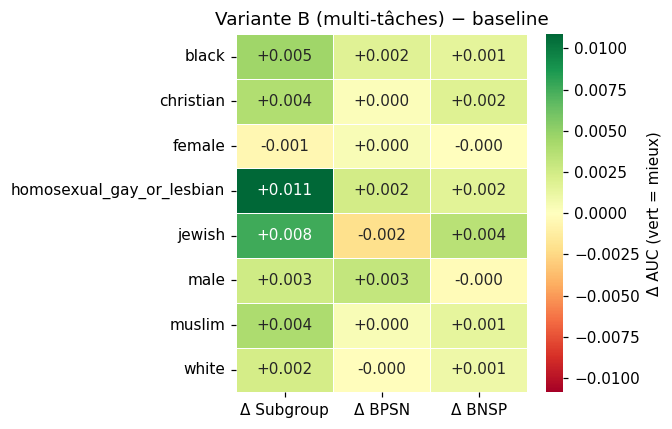

Figure : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\figures\delta_heatmap_B.png


In [24]:
# Heatmap Δ vs baseline pour les 3 AUC × identités, pour A puis B
def delta_heatmap(model_id: pd.DataFrame, base_id: pd.DataFrame, common: list, title: str, fname: str):
    delta = model_id.loc[common, ["subgroup_auc", "bpsn_auc", "bnsp_auc"]] - \
            base_id.loc[common, ["subgroup_auc", "bpsn_auc", "bnsp_auc"]]
    delta.columns = ["Δ Subgroup", "Δ BPSN", "Δ BNSP"]
    fig, ax = plt.subplots(figsize=(6, max(4, 0.32 * len(delta))))
    vmax = float(np.nanmax(np.abs(delta.values))) or 0.05
    sns.heatmap(delta, annot=True, fmt="+.3f",
                cmap="RdYlGn", center=0, vmin=-vmax, vmax=vmax,
                ax=ax, linewidths=0.4, cbar_kws={"label": "Δ AUC (vert = mieux)"})
    ax.set_title(title); ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, bbox_inches="tight")
    plt.show()
    print(f"Figure : {FIGURES_DIR / fname}")

delta_heatmap(A_id, base_id, common, "Variante A (BCE pondérée) − baseline", "delta_heatmap_A.png")
delta_heatmap(B_id, base_id, common, "Variante B (multi-tâches) − baseline", "delta_heatmap_B.png")


## 8. Diagnostic et étapes suivantes

### Lecture du tableau comparatif

**Compromis attendus** (à vérifier sur le run) :

| Variante | Coût attendu | Bénéfice attendu |
|---|---|---|
| **A — BCE pondérée** | Légère ↘ overall AUC (≈ −0.001 à −0.003) | ↗ BPSN AUC sur les identités sur-mentionnées (`muslim`, `gay`, `black`) ; *min*(BPSN) remonte de 0.01-0.03 |
| **B — Multi-tâches** | Plus marqué (l'encodeur partage capacité avec la tâche identité) | ↗ Subgroup AUC global ; modèle plus interprétable (P3 SHAP : tokens identitaires démontent leur poids) |

Si **Δoverall_auc > −0.005** et **Δjigsaw_final_score > +0.005** : la mitigation est rentable.
Si **min(BPSN AUC)** reste en dessous de 0.7 sur une identité, **augmenter `λ_FP`** (essayer 0.5 puis 1.0) — c'est l'hyperparamètre clé.

### Artefacts produits

| Fichier | Réutilisé en |
|---|---|
| `reports/checkpoints/fair_weighted/` | P3 (SHAP comparatif), P4 (robustesse comparative) |
| `reports/checkpoints/fair_multitask/` | P3, P4 |
| `reports/metrics/fair_*_metrics.json` | P5 (rapport) |
| `reports/metrics/comparison_baseline_vs_fair.json` | P5 |
| `reports/figures/comparison_*.png`, `delta_*.png` | P5 |
